In [ ]:
# =========================
# CELL 1: Mount Drive + Log Path
# =========================

from google.colab import drive
drive.mount("/content/drive")

import os

LOG_PATH = "/content/drive/MyDrive/Thesis/FineTunning/llama_training_logs.json"

print("Training logs will be saved to:")
print(LOG_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training logs will be saved to:
/content/drive/MyDrive/Thesis/FineTunning/llama_training_logs.json


In [ ]:
# =========================
# CELL 1: Libraries + Drive + Paths (Llama-3.1-8B-Instruct QLoRA)
# After install: Runtime -> Restart runtime
# =========================

!pip -q install -U "transformers>=4.46.0" "datasets>=2.19.0" "accelerate>=0.30.1" \
                   "peft>=0.11.1" "bitsandbytes>=0.43.1" "safetensors>=0.4.3" "huggingface_hub>=0.23.0"

import torch, pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer, default_data_collator,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from google.colab import drive

drive.mount("/content/drive")

TRAIN_PATH  = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_train.csv"
TEST_PATH   = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_test.csv"

OUT_DIR     = "/content/drive/MyDrive/Thesis/FineTunning/llama31_out_lbl"
ADAPTER_DIR = "/content/drive/MyDrive/Thesis/FineTunning/llama31_lora_adapter_lbl"

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("Torch:", torch.__version__)
import transformers
print("Transformers:", transformers.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Torch: 2.10.0+cu128
Transformers: 5.3.0


In [ ]:
# =========================
# CELL 2: Fine-tune (QLoRA) + Oversample minority class
# Targets: EXACTLY "Radiotherapy" or "No radiation"
# =========================

# If you get 401/403 for Meta models, do this once:
# from huggingface_hub import login
# login()

df = pd.read_csv(TRAIN_PATH)
df.columns = df.columns.str.strip()
print("Train shape:", df.shape)

def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    if s == "no radiation":
        return "No radiation"
    return "No radiation"

# ---- Oversample minority class (prevents "always No radiation") ----
tmp = df.copy()
tmp["label"] = tmp["Radiotherapy"].apply(normalize_label)

counts = tmp["label"].value_counts()
print("\nLabel counts (before):\n", counts)

df_no  = tmp[tmp["label"] == "No radiation"].copy()
df_yes = tmp[tmp["label"] == "Radiotherapy"].copy()

if len(df_yes) == 0 or len(df_no) == 0:
    raise ValueError("One of the classes is empty after normalization. Check your Radiotherapy column values.")

df_yes_up = df_yes.sample(n=len(df_no), replace=True, random_state=42)
tmp_balanced = pd.concat([df_no, df_yes_up], ignore_index=True).sample(frac=1, random_state=42)
print("\nLabel counts (after):\n", tmp_balanced["label"].value_counts())

df_bal = tmp_balanced.drop(columns=["label"])

# ---- Prompt (train) ----
def make_prompt(row):
    return f"""Decide the radiotherapy outcome.

Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

def make_target(row):
    return normalize_label(row["Radiotherapy"])

rows = [{"prompt": make_prompt(df_bal.iloc[i]), "target": make_target(df_bal.iloc[i])}
        for i in range(len(df_bal))]
dataset = Dataset.from_list(rows)
print(dataset)

# ---- Tokenizer ----
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ---- 4-bit QLoRA base ----
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model)

# ---- LoRA ----
target_modules = ["q_proj","k_proj","v_proj","o_proj","up_proj","down_proj","gate_proj"]
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=target_modules
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ---- Tokenize + mask (train only on label tokens) ----
MAX_LEN = 256

def tokenize_and_mask(ex):
    prompt = ex["prompt"]
    target = ex["target"]
    full = prompt + "\n" + target

    enc = tokenizer(
        full,
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_attention_mask=True
    )

    prompt_ids = tokenizer(
        prompt,
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=True
    )["input_ids"]

    prompt_len = min(len(prompt_ids), MAX_LEN)
    labels = enc["input_ids"].copy()
    labels[:prompt_len] = [-100] * prompt_len
    labels = [(-100 if enc["attention_mask"][i] == 0 else labels[i]) for i in range(MAX_LEN)]
    enc["labels"] = labels
    return enc

tokenized = dataset.map(tokenize_and_mask, remove_columns=dataset.column_names)

# ---- Train ----
args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    num_train_epochs=1,          # start with 1; set 2 if you want stronger learning
    learning_rate=5e-5,
    bf16=torch.cuda.is_available(),
    fp16=False,
    logging_steps=25,
    save_steps=200,
    save_total_limit=2,
    report_to="none",
    optim="paged_adamw_8bit",
    max_grad_norm=1.0,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized,
    data_collator=default_data_collator
)

trainer.train()

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Adapter saved:", ADAPTER_DIR)

Train shape: (7551, 13)

Label counts (before):
 label
No radiation    5890
Radiotherapy    1661
Name: count, dtype: int64

Label counts (after):
 label
Radiotherapy    5890
No radiation    5890
Name: count, dtype: int64
Dataset({
    features: ['prompt', 'target'],
    num_rows: 11780
})


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


Map:   0%|          | 0/11780 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
25,0.318229
50,0.310243
75,0.292729
100,0.312135
125,0.261217
150,0.311730
175,0.292767
200,0.256820
225,0.284581
250,0.292541


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Adapter saved: /content/drive/MyDrive/Thesis/FineTunning/llama31_lora_adapter_lbl


In [ ]:
# =========================
# CELL 3: Save Training Logs
# =========================

import json

training_logs = trainer.state.log_history

print("Total log records:", len(training_logs))

with open(LOG_PATH, "w") as f:
    json.dump(training_logs, f)

print("Training logs saved to Google Drive:")
print(LOG_PATH)

Total log records: 30
Training logs saved to Google Drive:
/content/drive/MyDrive/Thesis/FineTunning/llama_training_logs.json


    step      loss
0     25  0.318229
1     50  0.310243
2     75  0.292729
3    100  0.312135
4    125  0.261217
5    150  0.311730
6    175  0.292767
7    200  0.256820
8    225  0.284581
9    250  0.292541
10   275  0.268458
11   300  0.281782
12   325  0.292793
13   350  0.289014
14   375  0.270927
15   400  0.275971
16   425  0.279154
17   450  0.283307
18   475  0.277830
19   500  0.290582
20   525  0.268305
21   550  0.286322
22   575  0.291354
23   600  0.278287
24   625  0.275507
25   650  0.289254
26   675  0.276599
27   700  0.275186
28   725  0.259379


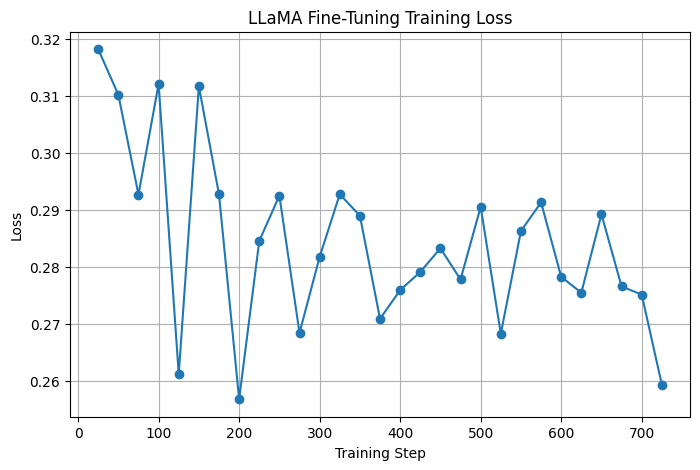

In [ ]:
# =========================
# CELL 6: Training Loss Visualization
# =========================

import pandas as pd
import matplotlib.pyplot as plt

log_df = pd.DataFrame(training_logs)

loss_df = log_df[log_df["loss"].notna()].copy()

if loss_df.empty:
    print("No loss values found.")
else:
    print(loss_df[["step", "loss"]])

    plt.figure(figsize=(8,5))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("LLaMA Fine-Tuning Training Loss")
    plt.grid(True)
    plt.show()

In [ ]:
import gc, torch

# try to delete common big objects created during training
for name in ["trainer", "model", "base_model", "base", "tokenized", "dataset", "tokenizer"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("CUDA mem (free,total):", torch.cuda.mem_get_info())

CUDA mem (free,total): (15452995584, 23659151360)


In [ ]:
# =========================
# LLAMA-3.1-8B - Inference (STRICT 2 OPTIONS) + Save CSV
# Fix: force model fully on GPU (no CPU/disk dispatch)
# =========================

import os
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from google.colab import drive

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

drive.mount("/content/drive")

MODEL_ID    = "meta-llama/Llama-3.1-8B-Instruct"
ADAPTER_DIR = "/content/drive/MyDrive/Thesis/FineTunning/llama31_lora_adapter_lbl"
TEST_PATH   = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_test.csv"

record_from = 21
record_to   = 35
SAVE_PATH   = f"/content/drive/MyDrive/Thesis/FineTunning/LLAMA31_only2_{record_from}_{record_to}.csv"

print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

# ---------- Load test ----------
test_df = pd.read_csv(TEST_PATH)
test_df.columns = test_df.columns.str.strip()
subset = test_df.iloc[record_from-1:record_to].copy().reset_index(drop=True)
print("Selected rows:", len(subset))

# ---------- Tokenizer ----------
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ---------- Load base model (4-bit) forced to GPU ----------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},          # <-- FORCE all layers to GPU 0
    low_cpu_mem_usage=True,
    trust_remote_code=True
)
base.config.use_cache = False
base.eval()

# ---------- Attach adapter ----------
model = PeftModel.from_pretrained(base, ADAPTER_DIR)
model.eval()

MAX_LEN = 256

def make_prompt(row):
    return f"""Decide the radiotherapy outcome.

Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

# ---------- Constrained decoding (only 2 labels) ----------
LABELS = ["Radiotherapy", "No radiation"]

def build_label_token_ids(tok, labels):
    seqs = []
    for lab in labels:
        for variant in [lab, " " + lab]:
            ids = tok(variant, add_special_tokens=False)["input_ids"]
            if ids:
                seqs.append(ids)
    uniq, seen = [], set()
    for s in seqs:
        t = tuple(s)
        if t not in seen:
            uniq.append(s)
            seen.add(t)
    return uniq

label_token_seqs = build_label_token_ids(tokenizer, LABELS)

def make_prefix_allowed_fn(prompt_len):
    eos = tokenizer.eos_token_id

    def prefix_allowed_tokens_fn(batch_id, input_ids):
        if input_ids.dim() == 1:
            seq = input_ids
        else:
            seq = input_ids[batch_id]

        gen = seq[prompt_len:].tolist()

        if len(gen) == 0:
            return sorted({seq_ids[0] for seq_ids in label_token_seqs})

        allowed = set()
        complete = False

        for seq_ids in label_token_seqs:
            if gen == seq_ids:
                complete = True
                continue
            if len(gen) < len(seq_ids) and gen == seq_ids[:len(gen)]:
                allowed.add(seq_ids[len(gen)])

        if complete and not allowed:
            return [eos]

        return list(allowed) if allowed else [eos]

    return prefix_allowed_tokens_fn

def predict_label(prompt):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]
    prefix_fn = make_prefix_allowed_fn(prompt_len)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=6,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            prefix_allowed_tokens_fn=prefix_fn
        )

    gen = out[0, prompt_len:]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

# ---------- Run ----------
preds = []
for i in range(len(subset)):
    pred = predict_label(make_prompt(subset.iloc[i]))
    preds.append(pred)
    print(f"Record {record_from+i}: {pred}")

# ---------- Save ----------
out_df = subset.copy()
out_df.insert(0, "RecordNo", list(range(record_from, record_to + 1)))
out_df = out_df.rename(columns={"Radiotherapy": "Control_Radiotherapy"})
out_df["Predicted_Radiotherapy"] = preds
out_df.to_csv(SAVE_PATH, index=False)
print("Saved:", SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Selected rows: 15


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Record 21: No radiation
Record 22: Radiotherapy
Record 23: No radiation
Record 24: No radiation
Record 25: Radiotherapy
Record 26: No radiation
Record 27: Radiotherapy
Record 28: No radiation
Record 29: No radiation
Record 30: Radiotherapy
Record 31: No radiation
Record 32: No radiation
Record 33: No radiation
Record 34: No radiation
Record 35: Radiotherapy
Saved: /content/drive/MyDrive/Thesis/FineTunning/LLAMA31_only2_21_35.csv


In [ ]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.mem_get_info())

NVIDIA L4
(4830920704, 23659151360)


In [ ]:
!pip -q install scikit-learn

Columns in out_df:
['RecordNo', 'Age', 'Sex', 'Marital status at diagnosis', 'Primary Site - labeled', 'Grade', 'T stage', 'N stage', 'M stage', 'Control_Radiotherapy', 'Surgical treatment', 'Chemotherapy', 'Survival months', 'Overall survival', 'Predicted_Radiotherapy']

True labels:
['No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'Radiotherapy', 'No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'Radiotherapy', 'Radiotherapy', 'No radiation', 'No radiation', 'No radiation', 'Radiotherapy']

Predicted labels:
['No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'Radiotherapy', 'No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'Radiotherapy', 'No radiation', 'No radiation', 'No radiation', 'No radiation', 'Radiotherapy']


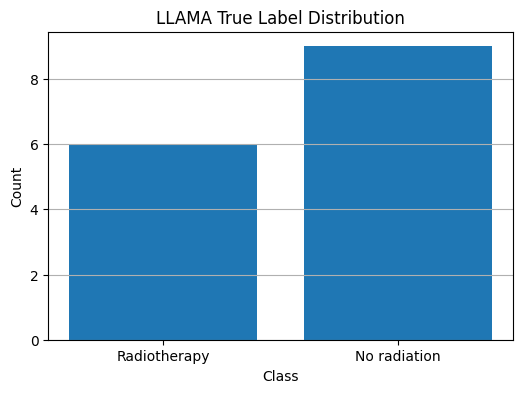

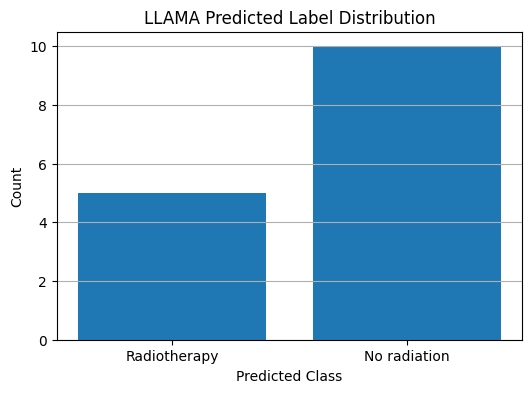

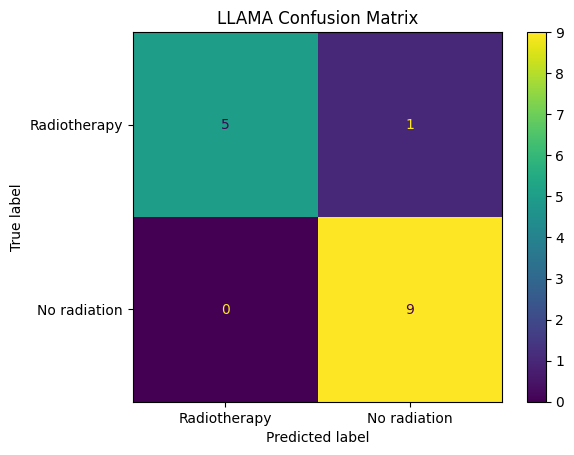


Classification Report:

              precision    recall  f1-score   support

Radiotherapy       1.00      0.83      0.91         6
No radiation       0.90      1.00      0.95         9

    accuracy                           0.93        15
   macro avg       0.95      0.92      0.93        15
weighted avg       0.94      0.93      0.93        15



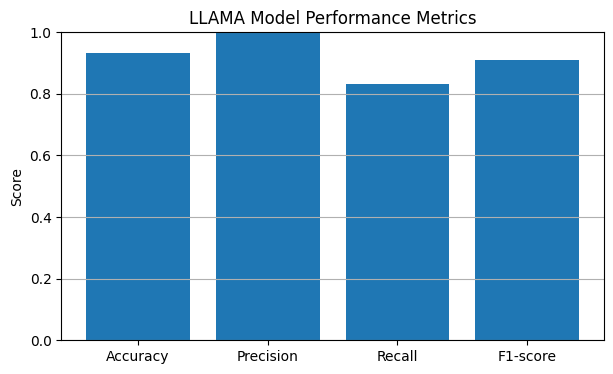

Accuracy : 0.9333
Precision: 1.0
Recall   : 0.8333
F1-score : 0.9091

Prediction Details:

    RecordNo        Actual     Predicted  Correct
0         21  No radiation  No radiation     True
1         22  Radiotherapy  Radiotherapy     True
2         23  No radiation  No radiation     True
3         24  No radiation  No radiation     True
4         25  Radiotherapy  Radiotherapy     True
5         26  No radiation  No radiation     True
6         27  Radiotherapy  Radiotherapy     True
7         28  No radiation  No radiation     True
8         29  No radiation  No radiation     True
9         30  Radiotherapy  Radiotherapy     True
10        31  Radiotherapy  No radiation    False
11        32  No radiation  No radiation     True
12        33  No radiation  No radiation     True
13        34  No radiation  No radiation     True
14        35  Radiotherapy  Radiotherapy     True


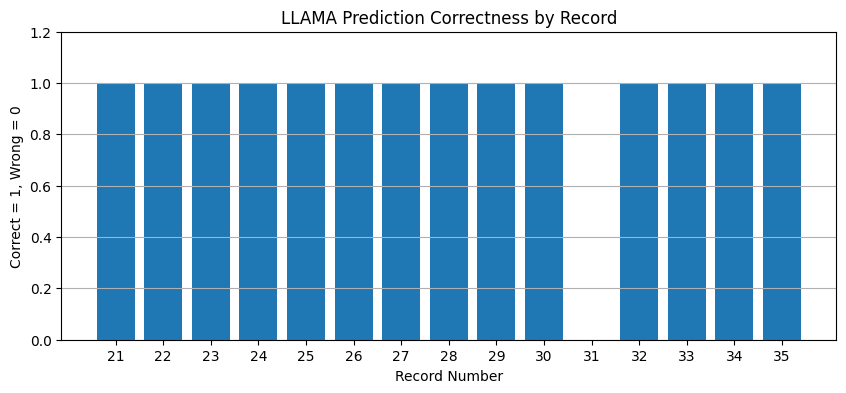

In [ ]:
# =========================
# LLAMA - CELL 3B: Evaluation Visualizations
# Uses out_df from CELL 3
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# -------------------------
# Check columns
# -------------------------
print("Columns in out_df:")
print(out_df.columns.tolist())

required_cols = ["Control_Radiotherapy", "Predicted_Radiotherapy"]
for col in required_cols:
    if col not in out_df.columns:
        raise ValueError(f"Column '{col}' not found in out_df")

# -------------------------
# Normalize labels
# -------------------------
def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    elif s == "no radiation":
        return "No radiation"
    else:
        return str(x).strip()

y_true = out_df["Control_Radiotherapy"].apply(normalize_label)
y_pred = out_df["Predicted_Radiotherapy"].apply(normalize_label)

labels = ["Radiotherapy", "No radiation"]

print("\nTrue labels:")
print(y_true.tolist())

print("\nPredicted labels:")
print(y_pred.tolist())

# -------------------------
# 1. True label distribution
# -------------------------
true_counts = y_true.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(true_counts.index, true_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("LLAMA True Label Distribution")
plt.grid(axis="y")
plt.show()

# -------------------------
# 2. Predicted label distribution
# -------------------------
pred_counts = y_pred.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(pred_counts.index, pred_counts.values)
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.title("LLAMA Predicted Label Distribution")
plt.grid(axis="y")
plt.show()

# -------------------------
# 3. Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("LLAMA Confusion Matrix")
plt.show()

# -------------------------
# 4. Metrics
# -------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
recall = recall_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(7, 4))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("LLAMA Model Performance Metrics")
plt.grid(axis="y")
plt.show()

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

# -------------------------
# 5. Row-wise correctness plot
# -------------------------
result_df = pd.DataFrame({
    "RecordNo": out_df["RecordNo"],
    "Actual": y_true,
    "Predicted": y_pred
})

result_df["Correct"] = result_df["Actual"] == result_df["Predicted"]

print("\nPrediction Details:\n")
print(result_df)

plt.figure(figsize=(10, 4))
plt.bar(result_df["RecordNo"].astype(str), result_df["Correct"].astype(int))
plt.xlabel("Record Number")
plt.ylabel("Correct = 1, Wrong = 0")
plt.title("LLAMA Prediction Correctness by Record")
plt.ylim(0, 1.2)
plt.grid(axis="y")
plt.show()

In [ ]:
# =========================
# LLAMA - CELL 2B: Training Loss Curve
# =========================

import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)

loss_df = log_df[log_df["loss"].notna()].copy()

if loss_df.empty:
    print("No loss values found in trainer.state.log_history")
else:
    print(loss_df[["step", "loss"]])

    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("LLAMA Fine-Tuning Training Loss")
    plt.grid(True)
    plt.show()

In [ ]:
# =========================
# LLAMA - Training Loss Curve
# =========================

import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)

loss_df = log_df[log_df["loss"].notna()].copy()

print(loss_df[["step","loss"]])

plt.figure(figsize=(8,5))
plt.plot(loss_df["step"], loss_df["loss"], marker="o")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("LLaMA-3.1 Fine-Tuning Training Loss")
plt.grid(True)
plt.show()